## plot HST observation

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import rotate

# Load FITS image
with fits.open('/home/linfel/linfel_data/hst_raw_JianyangLi/17293/stack_all.fits') as hdul:
    hst_data = hdul[0].data  # assuming image is in HDU 0
    header = hdul[0].header

# Extract metadata
orientat = header.get('ORIENTAT', 'N/A')
utc_mid = header.get('UTC-MID', 'N/A')

# clean data, set background to 1e-20, and logarithmic brightness scale
hst_data[hst_data < 0] = 0
hst_data[np.isnan(hst_data)] = 0
log10_hst = np.log10(hst_data + 1e-20)

In [2]:
# # clean data and logarithmic brightness scale
# hst_data[hst_data < 0] = np.nan
# log_hst = np.copy(hst_data)
# mask = hst_data >= 0
# log_hst[mask] = np.log10(hst_data[mask])

In [3]:
# coordinates are in 'Sun Body Center'
r_Didy_sys_bary = np.array([-1.252938965664409E+08, 1.736400744097055E+08, 1.017805938869286E+07])  # km
r_Hubble = np.array([-1.058142769367994E+08, 1.027338649631926E+08, -2.109203366145492E+03])        # km
target_distance = np.linalg.norm(r_Didy_sys_bary - r_Hubble)  # km

# Hubble pixel size
pixel_arcsec = 0.04
range_km = target_distance
pixel_fov = np.deg2rad(pixel_arcsec / 3600)  # pixel field of view in rad
pixel_km = 2 * range_km * np.tan(pixel_fov/2)

# Axes in km
ny, nx = hst_data.shape
x_km = np.arange(nx+1) * pixel_km
y_km = np.arange(ny+1) * pixel_km
x_km = x_km - x_km[-1]/2
y_km = y_km - y_km[-1]/2

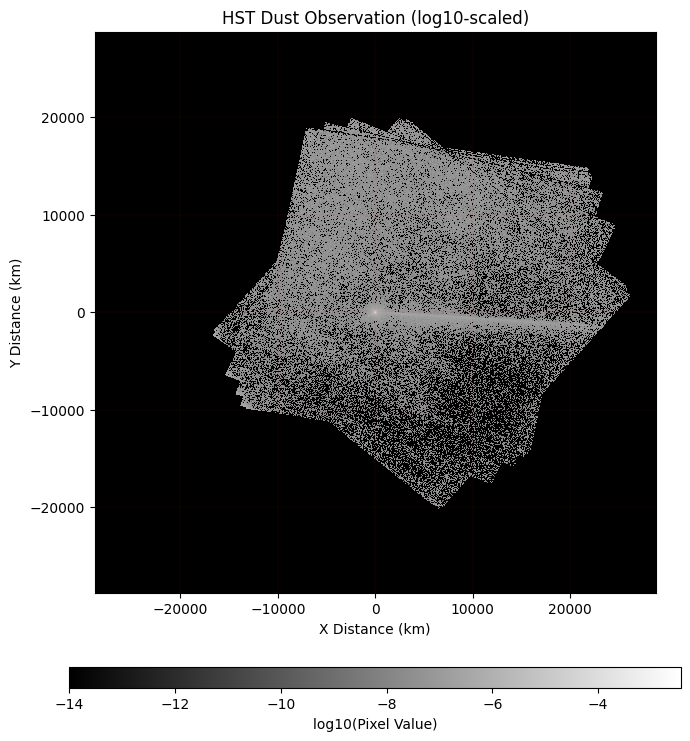

In [5]:
# Plot HST observation
X, Y = np.meshgrid(x_km, y_km)   # km

plt.figure(figsize=(8, 8))
pc = plt.pcolormesh(X, Y, log10_hst, cmap='gray', shading='auto', vmin=-14, vmax=np.nanmax(log10_hst))

plt.xlabel('X Distance (km)')
plt.ylabel('Y Distance (km)')
plt.title('HST Dust Observation (log10-scaled)')
plt.grid(True, linestyle='--', linewidth=0.1, color='red', alpha=0.7)

cbar = plt.colorbar(pc, orientation='horizontal', pad=0.1, shrink=0.8, aspect=30)  # pad adjusts spacing
cbar.set_label(r'$\log_{10}$(Pixel Value)')

# Set axis limits
plt.gca().set_aspect('equal', adjustable='box')
#plt.xlim(x_km[0], x_km[-1])
#plt.ylim(y_km[0], y_km[-1])

plt.tight_layout()
plt.savefig('hst_dust_observation_131.29_.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

#### check where NAN and negative values are

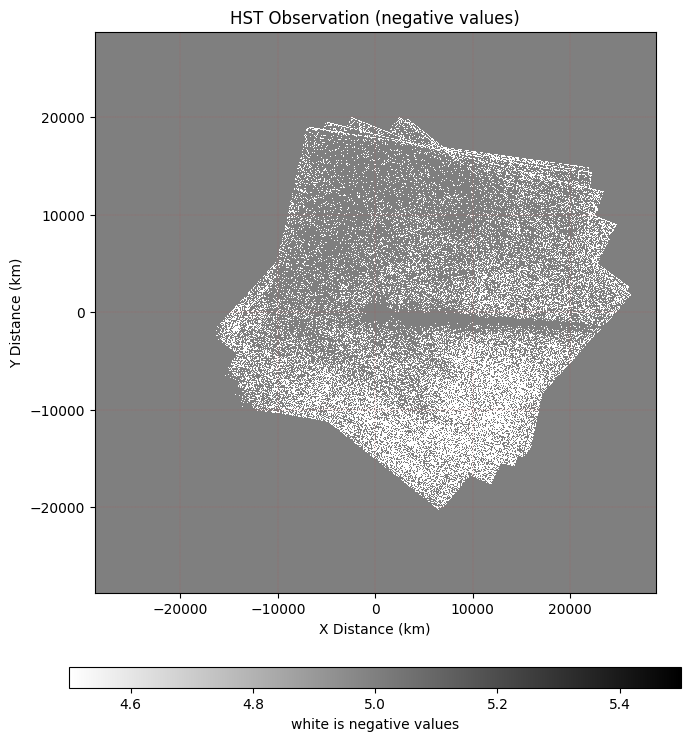

In [13]:
# show negative values in red color
plot_data = np.where(hst_data < 0, np.nan, 5)
#plot_data = np.where(np.isnan(hst_data), hst_data, 5)

# Plot
X, Y = np.meshgrid(x_km, y_km)   # km

plt.figure(figsize=(8, 8))
pc = plt.pcolormesh(X, Y, plot_data, cmap='binary')

plt.xlabel('X Distance (km)')
plt.ylabel('Y Distance (km)')
plt.title('HST Observation (negative values)')
plt.grid(True, linestyle='--', linewidth=0.1, color='red', alpha=0.7)

cbar = plt.colorbar(pc, orientation='horizontal', pad=0.1, shrink=0.8, aspect=30)  # pad adjusts spacing
cbar.set_label('white is negative values')

# Set axis limits
plt.gca().set_aspect('equal', adjustable='box')
#plt.xlim(x_km[0], x_km[-1])
#plt.ylim(y_km[0], y_km[-1])

plt.tight_layout()
plt.savefig('negative_values.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

#### Pixel location of the maximam intensity

In [6]:
flat_index = np.nanargmax(log10_hst)
i, j = np.unravel_index(flat_index, log10_hst.shape)
print(f"Maximum at (i, j) = ({i}, {j}) with value = {log10_hst[i, j]}")

Maximum at (i, j) = (2000, 2000) with value = -2.436722993850708


## Fit simulation with observation

In [4]:
import numpy as np
def rotate_coords(x, y, angle_deg, center=(0, 0)):
    """
    Rotate coordinates (x, y) by angle_deg around a given center.

    Parameters:
    - x, y: float or np.array of coordinates
    - angle_deg: rotation angle in degrees (positive = counterclockwise)
    - center: (x0, y0) tuple for rotation center (default is origin)

    Returns:
    - x_rot, y_rot: rotated coordinates
    """
    angle_rad = np.radians(angle_deg)

    x0, y0 = center

    x_rot = np.cos(angle_rad) * (x - x0) - np.sin(angle_rad) * (y - y0) + x0
    y_rot = np.sin(angle_rad) * (x - x0) + np.cos(angle_rad) * (y - y0) + y0

    return x_rot, y_rot

In [5]:
import numpy as np
import os, pickle
import matplotlib.pyplot as plt
from ReadParticle import read_particle_frames
import miepython as mie

# data path
data_rootdir = "/home/linfel/linfel_data/ejecta_exp_datahigh/day131.29_pkl"
filenames = [os.path.join(data_rootdir, f"particle_{i:03d}_day131.29.pkl") for i in range(9, 22)]

# Ensure output directory exists for saving frames
output_dir = "/home/linfel/linfel_data/ejecta_exp_datahigh/postprocess/plot_d131.29"
os.makedirs(output_dir, exist_ok=True)

# matrix convert vector from 'Sun Body Center' to 'Didymos System Barycenter'
SBC_rotate_DSB = np.array([[-0.703595792353257, -0.710438191316344, 0.015183454875444],
                          [ 0.702824020343859, -0.692584740738747,  0.16237232930379 ],
                          [-0.104839674791979,  0.124915784491013,  0.986612735258626]])

# sky north vector and convert it to 'Didymos System Barycenter' frame
sky_north = np.array([0, 0, 1])
r_sky_north = np.dot(SBC_rotate_DSB, sky_north.T)

# optical parameters
m = 1.7 - 0.01j           # refractive index of particle
lambda0 = 500e-9  # wavelength in vacuum (m)

# pixel dimension parameters
nx = 4001  # number of bins in x axis
ny = 4001   # number of bins in y axis

xedges = x_km * 1e3
yedges = y_km * 1e3

In [6]:
inten_sets = []

for file in filenames:
    # Read particle data
    with open(file, 'rb') as f:
        data = pickle.load(f)
        p_t = data['p_t']
        radii_dust = data['radii_dust']
        day = data['day']

    # position vector
    r_sun = p_t[2, 1:4]    # [x, y, z] of the Sun
    r_earth = p_t[3, 1:4]  # [x, y, z] of the Earth   (as a proxy of HST)
    r_dust = p_t[4:, 1:4]  # [x, y, z] of all dust particles

    # calculate the two basis vectors of the projection plane
    l1 = np.cross(r_sky_north, r_earth)
    l2 = np.cross(r_earth, l1)
    l1 = l1 / np.linalg.norm(l1)
    l2 = l2 / np.linalg.norm(l2)

    # create an array to record coordinates of particles projected onto the plane
    p_projected = np.zeros((len(p_t),3), dtype=float)
    p_projected[:, 0] = p_t[:, 0]                  # copy the column of particle ID
    p_projected[:, 1] = np.dot(p_t[:, 1:4], l1)    # x coordinate
    p_projected[:, 2] = np.dot(p_t[:, 1:4], l2)    # y coordinate

    # rotate particles with an angle on the projected plane
    # This step is to align simulated tail with observation in a line
    p_projected[:, 1], p_projected[:, 2] = rotate_coords(p_projected[:, 1], p_projected[:, 2], 0.)
    
    """2D density histogram"""
    hist_data = p_projected[4:]

    # Extract x and y projected coordinates
    x_proj = hist_data[:, 1]
    y_proj = hist_data[:, 2]

    # Mask out particles outside of range
    mask = (
        (x_proj >= xedges[0]) & (x_proj <= xedges[-1]) &
        (y_proj >= yedges[0]) & (y_proj <= yedges[-1])
    )
    x_filtered = x_proj[mask]
    y_filtered = y_proj[mask]

    # Create 2D histogram
    px_den, _, _ = np.histogram2d( # particle density of each pixel
        x_filtered,        # x coordinate
        y_filtered,        # y coordinate
        bins=[xedges, yedges],
        density=False  # Set True if you want normalized density
    )

    # set weight
    # W = 1e6
    # weight = 10 ** ((np.log10(radii_dust)+1) * np.log10(W) / (-3))    
    weight = 1

    # scattering intensity (assume scattering phase angle constant for all particles)
    qext, qsca, qback, g = mie.efficiencies(m, 2*radii_dust, lambda0)
    p_func = 1
    px_inten = qsca * (np.pi * radii_dust**2) * px_den * weight * p_func
    px_inten = px_inten.T

    inten_sets.append(px_inten)

sim_stack = np.stack(inten_sets, axis=-1)            # shape: (ny, nx, n_sizes)

In [7]:
# set fitting input X and Y
fit_input_X = sim_stack.reshape(-1, len(filenames))  # shape: (ny*nx, n_sizes)
fit_input_Y = hst_data.flatten()                     # shape: (ny*nx)

# create a mask of HST meaningful signal (pixels of background signal 1e-20 are not used for fitting)
meaningful_signal_mask = np.log10(fit_input_Y + 1e-20) > -20.0

# get the meaningful pixels from the HST data and simulated data using the mask
fit_input_Y_filtered = fit_input_Y[meaningful_signal_mask]
fit_input_X_filtered = fit_input_X[meaningful_signal_mask, :]

# --- min/max values ---
sim_min = np.min(fit_input_X_filtered)
sim_max = np.max(fit_input_X_filtered)
hst_min = np.min(fit_input_Y_filtered)
hst_max = np.max(fit_input_Y_filtered)

# --- Formatted Print Statement ---
# The f-string formatting aligns the text and numbers into clean columns.
# :<20 means left-align in a 20-character space.
# :>15.2e means right-align in a 15-character space, formatted in scientific notation with 2 decimals.
print(f"{'':<20} {'min':>15} {'max':>15}")
print("-" * 55) # Optional: adds a separator line for clarity
print(f"{'Simulation':<20} {sim_min:>15.2e} {sim_max:>15.2e}")
print(f"{'HST Observation':<20} {hst_min:>15.2e} {hst_max:>15.2e}")

                                 min             max
-------------------------------------------------------
Simulation                  0.00e+00        1.16e+00
HST Observation             1.16e-14        3.66e-03


In [8]:
import numpy as np
from scipy.optimize import least_squares

def residuals(weights, I_models, I_obs):
    # 权重不能为负
    if np.any(weights < 0):
        return np.inf # 返回一个巨大的误差

    # 计算模型的总光强 (加法模型)
    I_fit = np.dot(I_models, weights)

    # 计算对数空间的残差
    # 为避免 log(0) 错误，给强度加上一个极小值
    epsilon = 1e-20
    log_diff = np.log10(I_obs + epsilon) - np.log10(I_fit + epsilon)
    return log_diff

# guess an intial weights (e.g. all ones)
#initial_weights = np.ones(fit_input_X_filtered.shape[1])
initial_weights = np.array([1.48607575e-01, 2.03574515e-01, 3.44638220e-01, 4.84672084e-01,
                            5.36902768e-01, 5.75193493e-01, 6.08559074e-01, 5.99757568e-01,
                            5.61236310e-01, 4.91978292e-01, 3.86263984e-01, 2.45922593e-01,
                            7.13588707e-09])
# 进行非线性最小二乘拟合
result = least_squares(
    residuals,
    initial_weights,
    args=(fit_input_X_filtered, fit_input_Y_filtered)
)

# 拟合出的权重就是您要的粒子数密度的倍数
final_weights = result.x
print("Fitted weights (particle number multipliers):\n", final_weights)

Fitted weights (particle number multipliers):
 [7.37381936e-02 3.66914915e-02 1.88897448e-02 9.17642966e-03
 4.54714102e-03 2.06906552e-03 6.42664155e-04 2.26147112e-04
 8.44544765e-05 2.70145589e-05 6.91225285e-06 1.89048032e-06
 5.05909312e-07]


In [18]:
# from numpy.linalg import lstsq
# weights, residuals, rank, s = lstsq(fit_input_X[valid], fit_input_Y[valid], rcond=None)

# from scipy.optimize import nnls
# weights, _ = nnls(fit_input_X, fit_input_Y)
# print("Weights of different sizes: [" + "  ".join(f"{w:.2e}" for w in weights) + "]")

In [9]:
# calculate weighed fitting values
I_fit = np.dot(fit_input_X, final_weights).reshape(np.shape(sim_stack)[:2])

# check the i,j index of the maximum pixel value
flat_index = np.argmax(I_fit)
i, j = np.unravel_index(flat_index, I_fit.shape)
print(f"Maximum at (i, j) = ({i}, {j}) with value = {I_fit[i, j]}")

Maximum at (i, j) = (1654, 2533) with value = 7.571204919642315e-07


#### modelfit_scatterplot

In [10]:
import numpy as np
import matplotlib.pyplot as plt

x_data = np.log10(I_fit.flatten() + 1e-20)
y_data = np.log10(hst_data.flatten() + 1e-20)

# Find the combined min and max for both axes
min_val = min(np.min(x_data), np.min(y_data))
max_val = max(np.max(x_data), np.max(y_data))

# Add a little padding to the range
padding = (max_val - min_val) * 0.05
axis_min = min_val - padding
axis_max = max_val + padding
axis_limits = [axis_min, axis_max]

bin_edges = np.linspace(axis_min, axis_max, 251)

# two kinds of mask
# mask 1: Create a mask to find where both I_fit and hst_data are at their floor value (1e-20)
zero_mask = (x_data <= -20) | (y_data <= -20.0)
num_zeros = np.sum(zero_mask)

x_data_filtered = x_data[~zero_mask]
y_data_filtered = y_data[~zero_mask]

# # mask 2: use the mask where only hst_data are meaningful (> 1e-20)
# x_data_filtered = x_data[meaningful_signal_mask]
# y_data_filtered = y_data[meaningful_signal_mask]

# create the 2D histogram for performance of model fit
_den, _, _ = np.histogram2d( # particle density of each pixel
    x_data_filtered,        # x coordinate
    y_data_filtered,        # y coordinate
    bins=[bin_edges, bin_edges],
    density=False  # Set True if you want normalized density
)
_den = _den.T

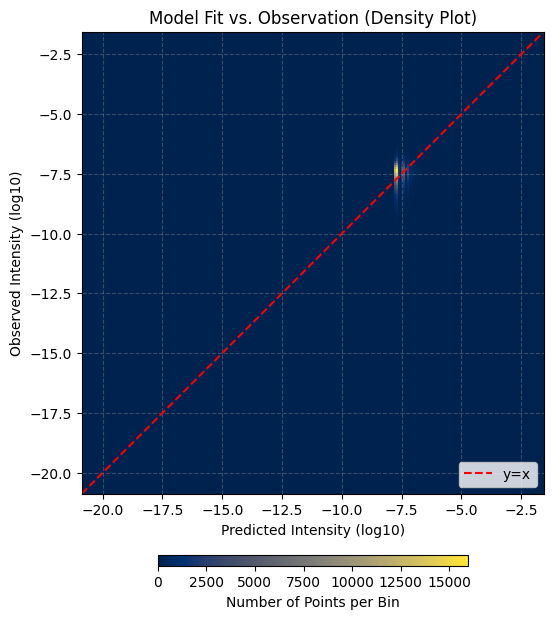

In [11]:
X, Y = np.meshgrid(bin_edges, bin_edges)

plt.figure(figsize=(8, 8))
pc = plt.pcolormesh(X, Y, _den, cmap='cividis', shading='auto')

# Draw the y=x reference line
plt.plot(axis_limits, axis_limits, 'r--', label='y=x') # 'r--' is a red dashed line

# colar bar
cbar = plt.colorbar(pc, orientation='horizontal', pad=0.1, shrink=0.5, aspect=30)
cbar.set_label(r'Number of Points per Bin')

plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(axis_limits)
plt.ylim(axis_limits)

plt.xlabel("Predicted Intensity (log10)")
plt.ylabel("Observed Intensity (log10)")
plt.title("Model Fit vs. Observation (Density Plot)")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.3)

plt.savefig(os.path.join(output_dir,'modelfit_scatterplot_1.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Fitted image

plots saved as /home/linfel/linfel_data/ejecta_exp_datahigh/postprocess/plot_d131.29/tail_fitting.png


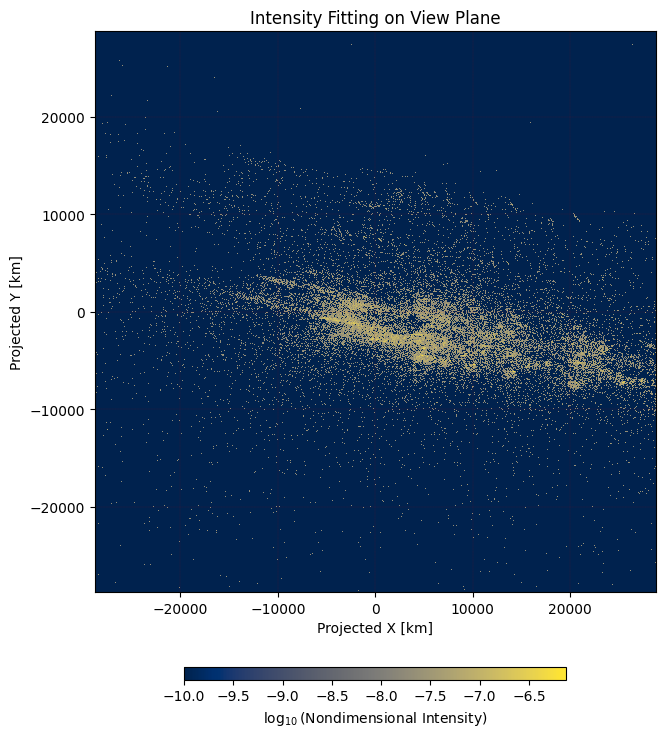

In [12]:
# Create meshgrid for bin edges
X, Y = np.meshgrid(xedges/1e3, yedges/1e3)   # km

# Plot using pcolor
plt.figure(figsize=(8, 8))

log10_fit = np.log10(I_fit + 1e-20)
pc = plt.pcolormesh(X, Y, log10_fit, cmap='cividis', shading='auto', vmin=-10, vmax=np.nanmax(log10_fit))

plt.xlabel('Projected X [km]')
plt.ylabel('Projected Y [km]')
plt.title('Intensity Fitting on View Plane')
plt.grid(True, linestyle='--', linewidth=0.1, color='red', alpha=0.7)
plt.gca().set_aspect('equal', adjustable='box')

# Colorbar
cbar = plt.colorbar(pc, orientation='horizontal', pad=0.1, shrink=0.5, aspect=30)
cbar.set_label(r'$\log_{10}$(Nondimensional Intensity)')

plt.tight_layout()
output_name = os.path.join(output_dir, "tail_fitting.png")
plt.savefig(output_name, dpi=300, bbox_inches='tight', pad_inches=0.1)
print(f"plots saved as {output_name}")
plt.show()
plt.close()

In [7]:
weight = np.array([6.81132697e-02, 7.51932702e-03 ,5.10925496e-03, 3.20836351e-03,
 1.44105043e-03 ,5.51079238e-04 ,2.74326045e-04, 1.19263117e-04,
 4.00361558e-05, 1.39723678e-05 ,5.43749190e-06 ,2.27081347e-06,
 9.46045715e-07])

radius = np.array([0.00158489, 0.00223872,
       0.00316228, 0.00446684, 0.00630957, 0.00891251, 0.01258925,
       0.01778279, 0.02511886, 0.03548134, 0.05011872, 0.07079458,
       0.1 ])

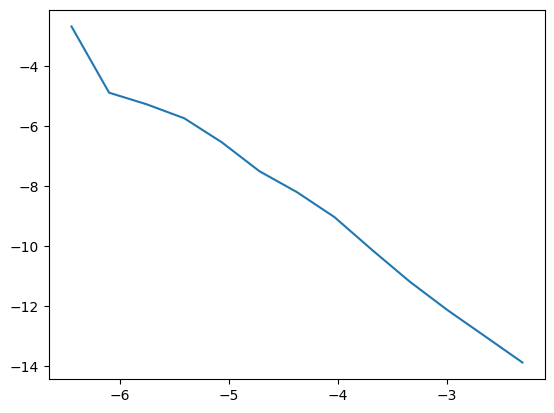

In [10]:
plt.plot(np.log(radius), np.log(weight))